In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
df = pd.read_csv("Shopping Trends And Customer Behaviour Dataset.csv")

In [143]:
df.head(10)

,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,5,6,46,Male,Sneakers,Footwear,20,Wyoming,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,6,7,63,Male,Shirt,Clothing,85,Montana,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,7,8,27,Male,Shorts,Clothing,34,Louisiana,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,8,9,26,Male,Coat,Outerwear,97,West Virginia,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,9,10,57,Male,Handbag,Accessories,31,Missouri,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


In [144]:
df.describe()

,Unnamed: 0,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1949.500000,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,1125.977353,15.207589,23.685392,0.716223,14.447125
min,0.000000,1.000000,18.000000,20.000000,2.500000,1.000000
25%,974.750000,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1949.500000,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.250000,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3899.000000,3900.000000,70.000000,100.000000,5.000000,50.000000


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              3900 non-null   int64  
 1   Customer ID             3900 non-null   int64  
 2   Age                     3900 non-null   int64  
 3   Gender                  3900 non-null   object 
 4   Item Purchased          3900 non-null   object 
 5   Category                3900 non-null   object 
 6   Purchase Amount (USD)   3900 non-null   int64  
 7   Location                3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [146]:
#Missing values
df.isnull().sum()

Unnamed: 0                0
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

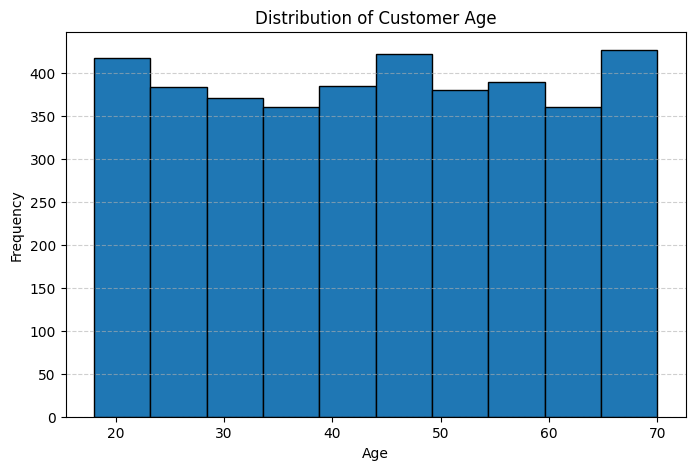

In [147]:
#Distribution of Age (Histogram)
plt.figure(figsize=(8,5))
plt.hist(df['Age'],bins=10,edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

The customer ages are distributed fairly evenly between 18 and 70 years. There is no dominant age group, suggesting that the dataset represents a broad range of customers across different age categories. The distribution appears approximately uniform, with no significant skewness or gaps.

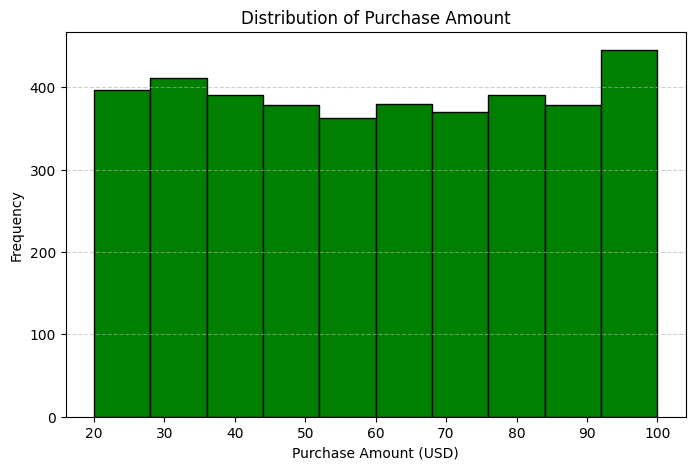

In [148]:
#Distribution of Purchase Amount (Histogram)
plt.figure(figsize=(8,5))
plt.hist(df['Purchase Amount (USD)'] , bins=10, color='green', edgecolor='black')
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Purchase amounts are distributed fairly evenly between $20 and $100, with no single purchase range dominating the dataset. This suggests that customers make purchases across a wide range of values, indicating a balanced mix of low-, medium-, and high-value transactions. Such a distribution may reflect a diverse product portfolio that appeals to customers with different spending capacities.

QUESTIONS ASKED IN FINDING OUT INSIGHTS

Do older customers spend more than younger customers?
Does gender influence purchase amount?
Which product category generates the highest purchase amounts?
Do customers with higher review ratings tend to spend more?
Do repeat customers spend more than first-time customers?

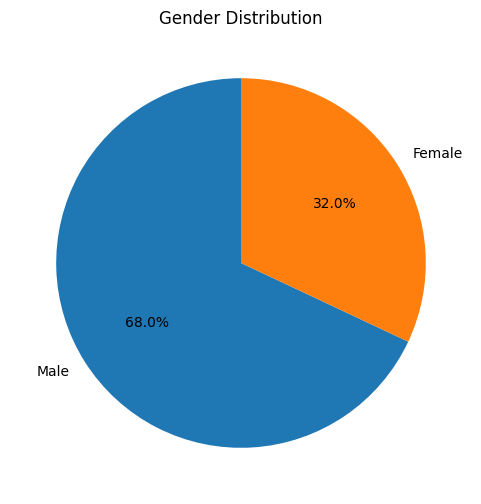

In [149]:
#Gender Distribution
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Gender Distribution')

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_29648\1591675469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


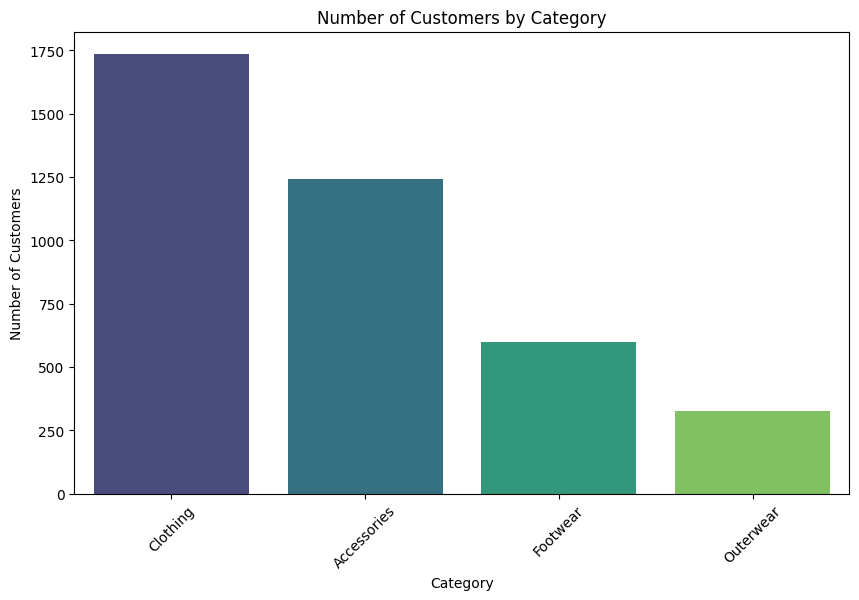

In [150]:
#Customers by Category
category_counts = df['Category'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Number of Customers by Category')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()


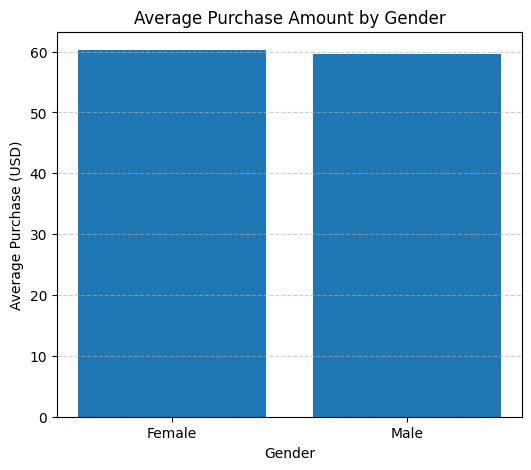

In [151]:
avg_purchase = df.groupby('Gender')['Purchase Amount (USD)'].mean()

plt.figure(figsize=(6,5))
plt.bar(avg_purchase.index, avg_purchase.values)

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.6, which='both')

plt.show()

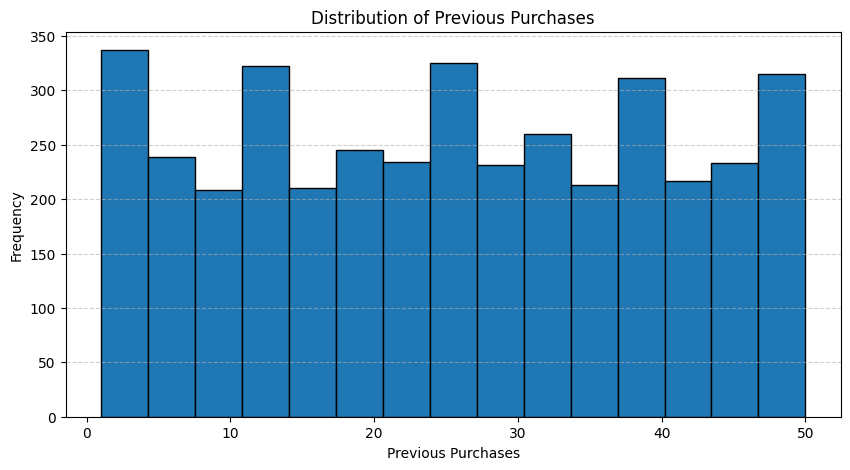

In [152]:
plt.figure(figsize=(10,5))
plt.hist(df['Previous Purchases'],bins=15,edgecolor='black')
plt.title('Distribution of Previous Purchases')
plt.xlabel('Previous Purchases')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

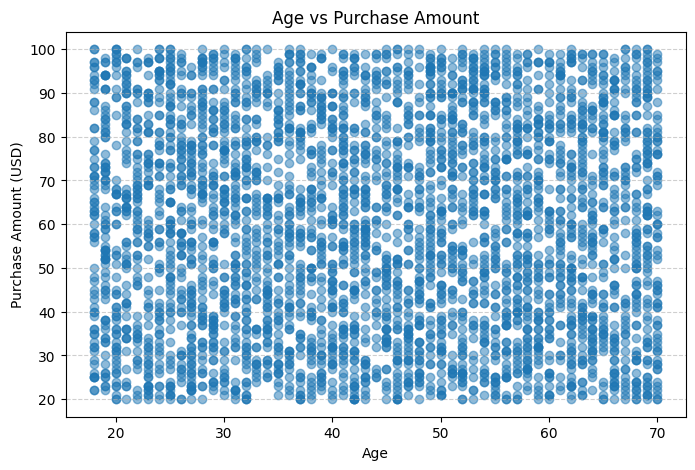

In [153]:
#Do older customers spend more than younger customers?
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Purchase Amount (USD)'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.title('Age vs Purchase Amount')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

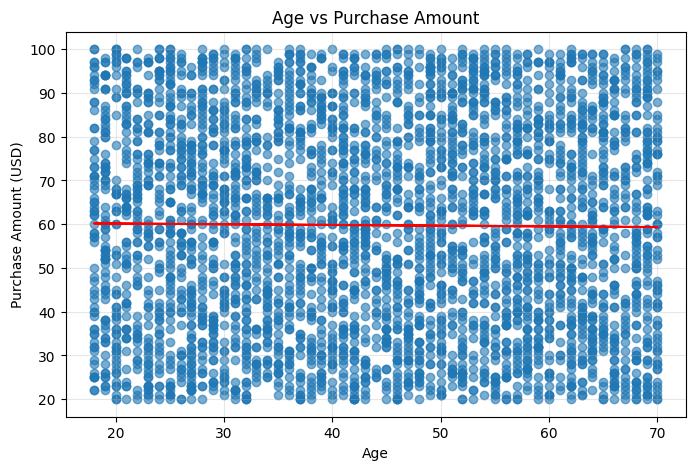

In [154]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['Age'],
    df['Purchase Amount (USD)'],
    alpha=0.6
)

z = np.polyfit(df['Age'], df['Purchase Amount (USD)'], 1)
p = np.poly1d(z)

plt.plot(df['Age'], p(df['Age']), color='red')

plt.title('Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')

plt.grid(alpha=0.3)

plt.show()

In [155]:
correlation = df['Age'].corr(df['Purchase Amount (USD)'])

print(f"Correlation: {correlation:.2f}")

Correlation: -0.01


The scatter plot shows no clear relationship between customer age and purchase amount. The correlation coefficient of -0.01 indicates an almost nonexistent linear relationship, suggesting that customers of different ages spend similar amounts on average. Therefore, age alone is not a useful predictor of purchase behavior in this dataset.

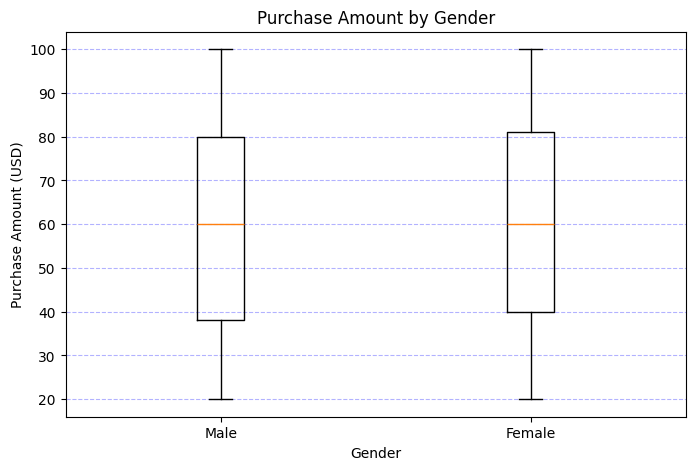

In [156]:
#Does gender influence purchase amount?
plt.figure(figsize=(8,5))

plt.boxplot(
[
        df[df['Gender'] == 'Male']['Purchase Amount (USD)'],
        df[df['Gender'] == 'Female']['Purchase Amount (USD)']
    ],
    tick_labels=['Male', 'Female'],
)

plt.title('Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount (USD)')

plt.grid(axis='y', alpha=0.3, color='blue', linestyle='--')

plt.show()


In [157]:
avg_purchase = df.groupby('Gender')['Purchase Amount (USD)'].mean()

print(avg_purchase)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


Male and female customers exhibit very similar purchasing behavior. The average purchase amount is approximately $59.54 for males and $60.25 for females, a difference of less than one dollar. The box plots also show similar medians and variability, suggesting that gender is not a significant factor influencing purchase amount in this dataset.

Which product category has the highest average purchase amount?

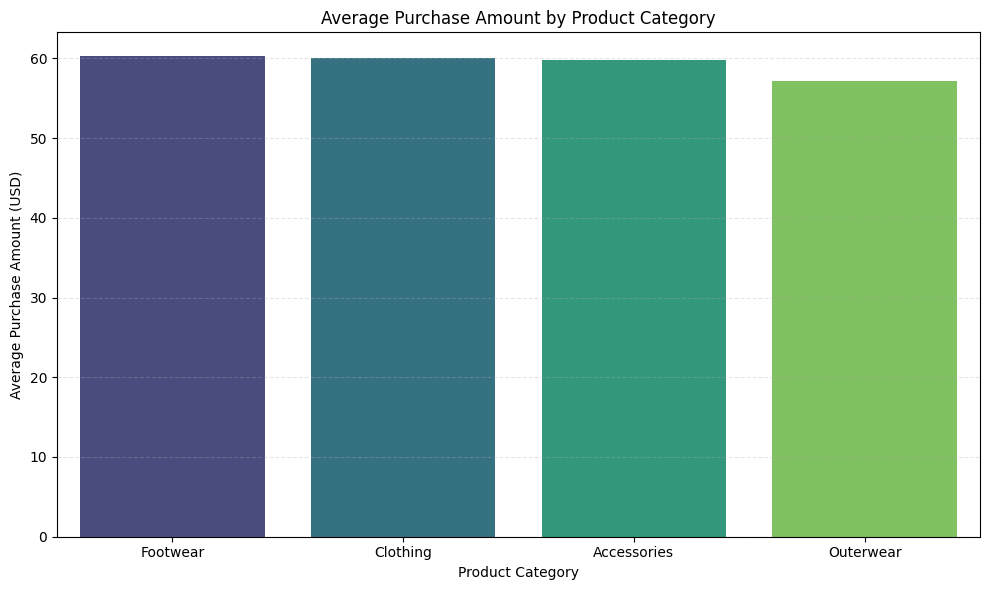

In [158]:
category_avg = (
    df.groupby('Category', as_index=False)['Purchase Amount (USD)']
      .mean()
      .sort_values(by='Purchase Amount (USD)', ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_avg,
    x='Category',
    y='Purchase Amount (USD)',
    hue='Category',
    legend=False,
    palette='viridis'
)

plt.title('Average Purchase Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Purchase Amount (USD)')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

Footwear has the highest average purchase amount, while Outerwear has the lowest. However, the differences between categories are relatively small, indicating that customers spend similar amounts across most product categories. Therefore, product category alone does not appear to have a strong influence on average purchase value.

Do customers with higher review ratings tend to spend more? 

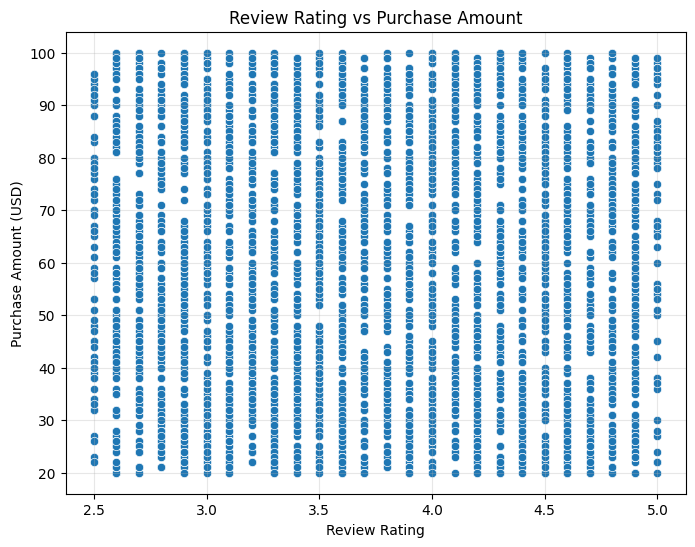

In [159]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Review Rating',
    y='Purchase Amount (USD)'
)

plt.title('Review Rating vs Purchase Amount')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')

plt.grid(alpha=0.3)

plt.show()

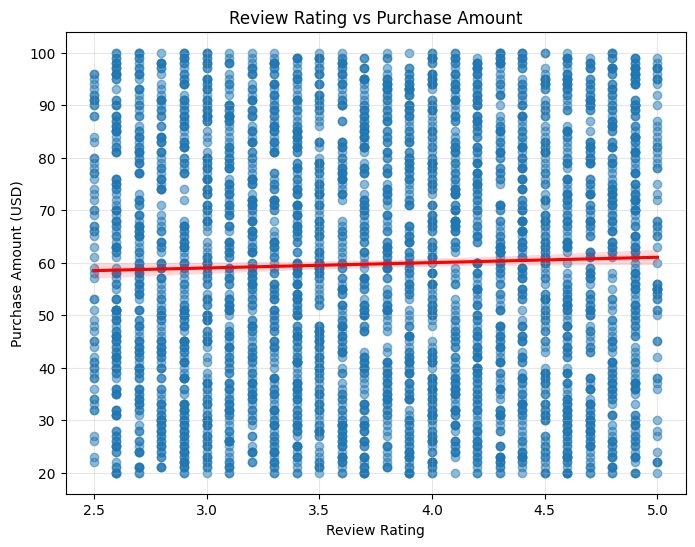

In [160]:
#Adding a trend line to the scatter plot
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Review Rating',
    y='Purchase Amount (USD)',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Review Rating vs Purchase Amount')
plt.xlabel('Review Rating')
plt.ylabel('Purchase Amount (USD)')

plt.grid(alpha=0.3)

plt.show()

In [161]:
correlation = df['Review Rating'].corr(df['Purchase Amount (USD)'])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.03


The regression line shows a slight positive trend between review ratings and purchase amounts. However, the wide spread of data points indicates that customers with both low and high ratings spend across a similar range. This suggests that review ratings have only a weak influence on purchase amount in this dataset.

Do customers with more previous purchases tend to spend more?

In [162]:
df['Previous Purchases'].describe()

count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: Previous Purchases, dtype: float64

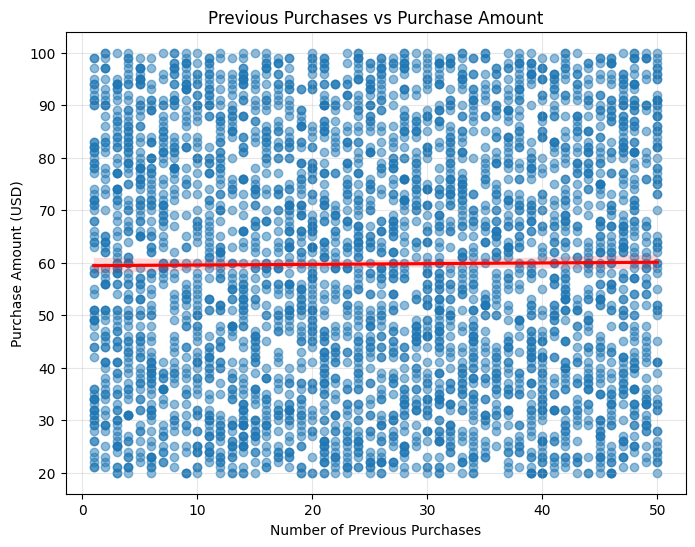

In [163]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Previous Purchases vs Purchase Amount')
plt.xlabel('Number of Previous Purchases')
plt.ylabel('Purchase Amount (USD)')

plt.grid(alpha=0.3)

plt.show()

In [164]:
correlation = df['Previous Purchases'].corr(df['Purchase Amount (USD)'])

print(f"Correlation: {correlation:.2f}")

Correlation: 0.01
